In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Set random seed for reproducibility
np.random.seed(42)


In [ ]:
def simulate_order_book(mid_price, num_levels=10, base_size=100, decay=0.7, spread=0.02, tick_size=0.01):
    """
    Generate bid and ask queues simulating realistic Level 2 order book snapshots.

    Returns:
        bids: list of (price, size), descending price
        asks: list of (price, size), ascending price
    """
    half_spread = spread / 2
    bid_prices = [round(mid_price - half_spread - i * tick_size, 2) for i in range(num_levels)]
    ask_prices = [round(mid_price + half_spread + i * tick_size, 2) for i in range(num_levels)]

    bids = []
    asks = []
    for i in range(num_levels):
        bid_size = max(1, int(base_size * (decay ** i) * np.random.uniform(0.8, 1.2)))
        ask_size = max(1, int(base_size * (decay ** i) * np.random.uniform(0.8, 1.2)))
        bids.append((bid_prices[i], bid_size))
        asks.append((ask_prices[i], ask_size))

    return bids, asks

# Example: generate a snapshot
mid_price = 100.00
bids, asks = simulate_order_book(mid_price)
print("Example Order Book Snapshot:")
print("Bids (price, size):", bids)
print("Asks (price, size):", asks)


Example Order Book Snapshot:
Bids (price, size): [(99.99, 94), (99.98, 76), (99.97, 42), (99.96, 28), (99.95, 24), (99.94, 13), (99.93, 13), (99.92, 7), (99.91, 5), (99.9, 3)]
Asks (price, size): [(100.01, 118), (100.02, 72), (100.03, 42), (100.04, 39), (100.05, 26), (100.06, 19), (100.07, 10), (100.08, 7), (100.09, 5), (100.1, 3)]


In [ ]:
def compute_temporary_impact(orderbook, mid_price, quantity):
    """
    Compute g_t(x) = Avg execution price - mid price for buys (use asks)

    Parameters:
    - orderbook: list of (price, size), sorted ascending by price (asks)
    - mid_price: float
    - quantity: int

    Returns:
    - impact: float, or None if insufficient liquidity
    """
    total_qty, total_cost = 0, 0.0
    for price, size in orderbook:
        take = min(quantity - total_qty, size)
        total_cost += price * take
        total_qty += take
        if total_qty >= quantity:
            break
    if total_qty < quantity:
        return None  # insufficient liquidity
    avg_price = total_cost / quantity
    return avg_price - mid_price


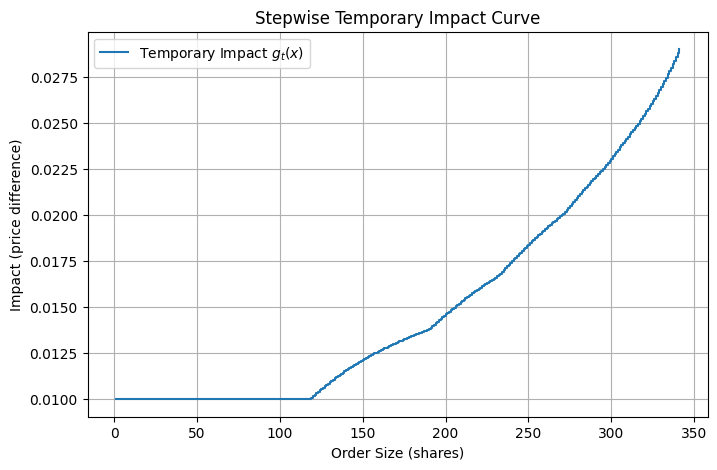

In [ ]:
max_size = sum(size for _, size in asks)
sizes = range(1, max_size + 1)
impacts = [compute_temporary_impact(asks, mid_price, q) for q in sizes]

plt.figure(figsize=(8, 5))
plt.step(list(sizes), impacts, where="post", label='Temporary Impact $g_t(x)$')
plt.xlabel('Order Size (shares)')
plt.ylabel('Impact (price difference)')
plt.title('Stepwise Temporary Impact Curve')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# Number of trading periods
N = 5

# Simulate drifting mid prices for these periods
mid_prices = mid_price + np.random.normal(0, 0.05, N)

# Generate order books for each time period
order_books_per_period = []
for t in range(N):
    _, asks_t = simulate_order_book(mid_prices[t])
    order_books_per_period.append(asks_t)

# Precompute g_i(x) for each period over a reasonable range
max_sizes = [sum(size for _, size in ob) for ob in order_books_per_period]
max_trade = min(500, min(max_sizes))  # limit max trade size for example

g_funcs = []
for i in range(N):
    impacts = []
    for q in range(max_trade + 1):
        if q == 0:
            impacts.append(0)
            continue
        imp = compute_temporary_impact(order_books_per_period[i], mid_prices[i], q)
        if imp is None:
            imp = impacts[-1]  # carry forward last known impact if insufficient liquidity
        impacts.append(imp)

    # Create interpolation function
    x_vals = np.array(range(max_trade + 1))
    y_vals = np.array(impacts)
    g_func = interp1d(x_vals, y_vals, kind='linear', fill_value='extrapolate', assume_sorted=True)
    g_funcs.append(g_func)


In [ ]:
S = 1000  # total shares to buy

def dp_trade_allocation(g_funcs, S, max_trade):
    N = len(g_funcs)
    INF = float('inf')
    DP = np.full((N + 1, S + 1), INF)
    DP[0, 0] = 0
    choice = np.zeros((N + 1, S + 1), dtype=int)

    block_size = 10  # discretize for performance
    possible_s_values = list(range(0, S + 1, block_size))
    possible_k_values = list(range(0, max_trade + 1, block_size))

    for i in range(1, N + 1):
        for s in possible_s_values:
            min_cost = INF
            opt_k = 0
            for k in possible_k_values:
                if k > s:
                    break
                prev_s = s - k
                cost = DP[i - 1, prev_s] + (g_funcs[i - 1](k) * k if k > 0 else 0)
                if cost < min_cost:
                    min_cost = cost
                    opt_k = k
            DP[i, s] = min_cost
            choice[i, s] = opt_k

    # Backtrack to find allocations
    alloc = np.zeros(N, dtype=int)
    rem = S
    for i in range(N, 0, -1):
        alloc[i - 1] = choice[i, rem]
        rem -= alloc[i - 1]
    return alloc

allocations = dp_trade_allocation(g_funcs, S, max_trade)

print("\nOptimal allocations across time periods:")
for i, qty in enumerate(allocations):
    print(f" Period {i+1}: {qty} shares")
print(f"Total allocated shares: {sum(allocations)}")



Optimal allocations across time periods:
 Period 1: 170 shares
 Period 2: 160 shares
 Period 3: 240 shares
 Period 4: 220 shares
 Period 5: 210 shares
Total allocated shares: 1000


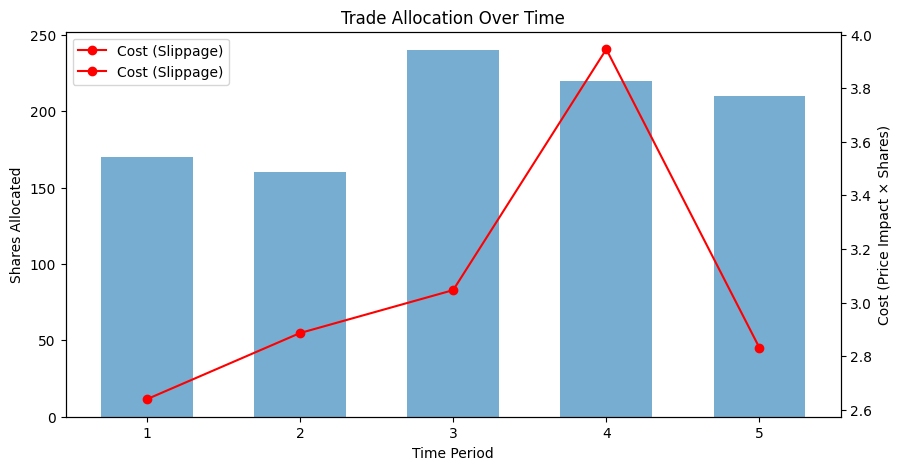

In [ ]:
# Calculate costs per period based on allocations
costs = [g_funcs[i](allocations[i]) * allocations[i] for i in range(N)]

plt.figure(figsize=(10, 5))
bar_width = 0.6
periods = range(1, N + 1)

plt.bar(periods, allocations, width=bar_width, alpha=0.6, label='Shares Allocated')
plt.xlabel('Time Period')
plt.ylabel('Shares Allocated')
plt.title('Trade Allocation Over Time')

ax2 = plt.twinx()
ax2.plot(periods, costs, 'r-o', label='Cost (Slippage)')
ax2.set_ylabel('Cost (Price Impact × Shares)')
ax2.grid(False)

lines_1, labels_1 = plt.gca().get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.show()
